### FTLE animations

In [1]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

In [2]:
from datetime import timedelta
import cartopy.crs as ccrs
import os
import xarray as xr
import numpy as np 
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cmocean

In [3]:
plt.rcParams['font.size'] = '12'

In [4]:
workingdir = '/g/data/jk72/mj0995/fsle'
os.chdir(workingdir) 

In [5]:
savepath = '/g/data/jk72/mj0995/figures'

In [6]:
d = 27.1 ## density level

region = 'DP'
extent = [295, 301, -59.5, -54.5] #meander
# extent = [284, 290, -61, -56] #upstream

# region = 'SEIR'
# extent = [149, 155, -57, -52] #meander
# extent = [140, 146, -56, -51] #upstream

## load FTLE datasets
ftle_bw_ds = xr.open_dataset(f'/g/data/jk72/mj0995/fsle/{region}/backward/{d}/FTLE_{region}_{d}.nc')
ftle_fw_ds = xr.open_dataset(f'/g/data/jk72/mj0995/fsle/{region}/forward/{d}/FTLE_{region}_{d}.nc')

In [7]:
### load SatGEM
satgem_sel = xr.open_dataset(f'/g/data/jk72/mj0995/satgem_{region}_on_d_noisy.nc')

In [8]:
### load particle positions
pc = 5 #percent noise
lon0 =  298 #143 #288 # #153 ##longitude section
n_days = 15 #advection time
t = '2018-11-20'
filename = f'/g/data/jk72/mj0995/output/{region}/MeridionalSection_{lon0}_{n_days}days_{pc}noise_{t}.zarr'

pfile = xr.open_zarr(filename)

In [9]:
### particle density levels 
dens = np.unique(pfile.z[:,0].values)

In [63]:
timestep = 6 #hours
sample_interval = int(24/timestep)
days = 15
t_ind = days*sample_interval

In [64]:
lt = -55.9 ## latitude of particle release column
i = np.where(pfile.lat[:, 0] == lt)[0][0]
origin_temp = pfile.temp[i:i+len(dens), t_ind-1]
origin_sal = pfile.sal[i:i+len(dens), t_ind-1]

## particle locations
lon = pfile.lon[i:i+len(dens), :t_ind+1].values
lat = pfile.lat[i:i+len(dens), :t_ind+1].values
time = pfile.time[i:i+len(dens), :t_ind+1].values

## plotting times for particle locations
plottimes = np.arange(time[-1, -1], np.nanmax(time)+ np.timedelta64(1, "D"), np.timedelta64(1, "D"))

In [65]:
# set time range
start, end = np.datetime64(t) - days, t
ftle_bw = ftle_bw_ds.sel(time = slice(start, end))
ftle_fw = ftle_fw_ds.sel(time = slice(start, end))

In [66]:
temp = satgem_sel.temp.sel(time = slice(start, end)).sel(density = d, method = 'nearest')

In [67]:
print(start, end)

2018-11-05 2018-11-20


In [ ]:
# t0 = time[0][-1]
t0 = '2018-11-10'

b = time == np.datetime64(t0)
# select particle on density level matching the FTLE field
d_ind = np.where(dens == d)[0][0]
print(dens[d_ind])
b_sel = time[d_ind] == np.datetime64(t0)

27.1


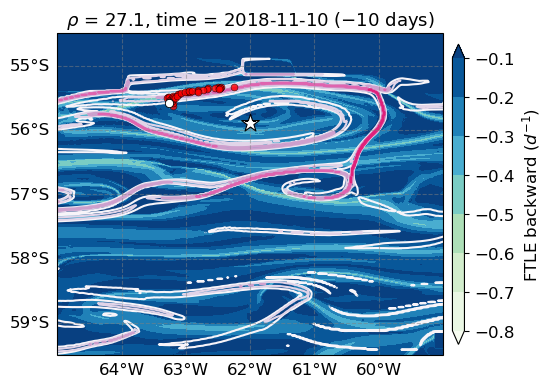

In [68]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# FTLE maps
im = ax.contourf(ftle_bw.lon, ftle_bw.lat, ftle_bw.lambda1.sel(time = t0, method='nearest').T, levels=np.arange(-0.8,0,0.1), cmap='GnBu', extend='both')
im2 = ax.contour(ftle_fw.lon, ftle_fw.lat, ftle_fw.lambda1.sel(time = t0, method='nearest').T, levels=np.arange(0.3,0.9,0.1), cmap='PuRd', extend='both')

# particle locations
p_sel = ax.plot(lon[d_ind, b_sel], lat[d_ind, b_sel], "o", c="w", markersize = 6, markeredgecolor='k', markeredgewidth = 0.6, transform=ccrs.PlateCarree(), zorder = 100)
p = ax.plot(lon[b], lat[b], "o", c="red", markersize = 5, markeredgecolor='k', markeredgewidth = 0.4, alpha = 0.8, transform=ccrs.PlateCarree(), zorder = 80)

# particle release location
ax.scatter(pfile.lon[i, 0].values, pfile.lat[i, 0].values, marker = '*', color = 'w', s = 180, edgecolors = 'k', linewidths = 0.8, zorder = 100, transform=ccrs.PlateCarree()) 

gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

plt.ylim(extent[2], extent[3])

# t0 = t0.astype('M8[D]')
days = (time[0, 0] - np.datetime64(t0)).astype('timedelta64[D]')
plt.title(r'$\rho$'+ f' = {d}, time = {t0} ($-${days})', fontsize = 13)

# cbar_ax = fig.add_axes([0.92, 0.18, 0.02, 0.63]) 
plt.colorbar(im, label=r'FTLE backward ($d^{-1}$)', aspect = 25, shrink = 0.65, pad = 0.02)
# plt.colorbar(im2, label=r'FTLE forward ($d^{-1}$)', aspect = 25, shrink = 0.65, pad = 0.02)
# cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
# cb.set_label(r'FTLE backward ($d^{-1}$)')
# cb.set_label(r'temp')

In [39]:
# name = f'{region}_FTLE_{lon0}_{lt}_{t0}_forward.png'
# fig.savefig(os.path.join(savepath, name), dpi = 500, bbox_inches='tight', pad_inches= 0.2)

In [69]:
## particle times
b = time == plottimes[0]

# select particle on density level matching the FTLE field
d_ind = np.where(dens == d)[0][0]
print(dens[d_ind])
b_sel = time[d_ind] == plottimes[0]

27.1


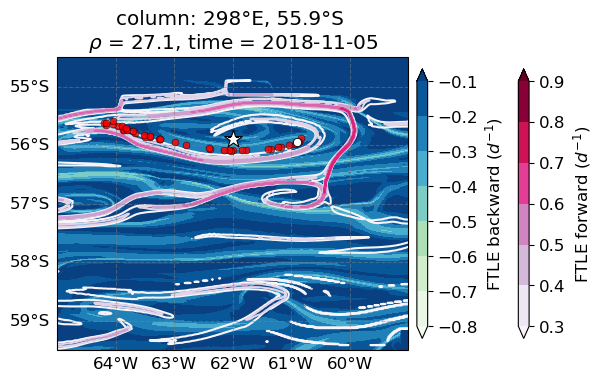

In [70]:
# Plot the initial frame
fig = plt.figure(figsize=(7,7))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# FTLE maps
im = ax.contourf(ftle_bw.lon, ftle_bw.lat, ftle_bw.lambda1.sel(time = t0, method='nearest').T, levels=np.arange(-0.8,0,0.1), cmap='GnBu', extend='both')
im2 = ax.contourf(ftle_fw.lon, ftle_fw.lat, ftle_fw.lambda1.sel(time = t0, method='nearest').T, levels=np.arange(0.3,0.9,0.1), cmap='PuRd', extend='both', zorder = 0)
ax.contour(ftle_fw.lon, ftle_fw.lat, ftle_fw.lambda1.sel(time = t0, method='nearest').T, levels=np.arange(0.3,0.9,0.1), cmap='PuRd', extend='both')

# particle release location
ax.scatter(pfile.lon[i, 0].values, pfile.lat[i, 0].values, marker = '*', color = 'w', s = 180, edgecolors = 'k', linewidths = 0.8, zorder = 100, transform=ccrs.PlateCarree()) 
# particle locations
p_sel = ax.plot(lon[d_ind, b_sel], lat[d_ind, b_sel], "o", c="w", markersize = 6, markeredgecolor='k', markeredgewidth = 0.6, transform=ccrs.PlateCarree(), zorder = 100)
p = ax.plot(lon[b], lat[b], "o", c="red", markersize = 5, markeredgecolor='k', markeredgewidth = 0.4, alpha = 0.8, transform=ccrs.PlateCarree(), zorder = 80)

# cartopy features
gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title(f"column: {lon0}°E, {lt*-1}°S \n" + r"$\rho$" + f" = {d}, " + "time = " + str(ftle_bw.coords['time'].values[0].astype('M8[D]')))
# ax.set_title(f"column: {360-lon0}°W, {lt*-1}°S \n" + r"$\rho$" + f" = {d}, " + "time = " + str(ftle_bw.coords['time'].values[0].astype('M8[D]')))
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.tick_params(axis='x', pad=50)

fig.colorbar(im2, ax=ax, label = r'FTLE forward ($d^{-1}$)', shrink = 0.5, aspect = 25, pad = 0.07)
fig.colorbar(im, ax=ax, label = r'FTLE backward ($d^{-1}$)', shrink = 0.5, aspect = 25, pad = 0.02)

# Next create a function that updates the values for the colormesh, contours, trajectory and title.
def animate(frame):
    
    ax.clear()
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    ## FLTE maps
    im = ax.contourf(ftle_bw.lon, ftle_bw.lat, ftle_bw.lambda1.isel(time = frame).T, levels=np.arange(-0.8,0,0.1), cmap='GnBu', extend='both')
    # im2 = ax.contourf(ftle_fw.lon, ftle_fw.lat, ftle_fw.lambda1.isel(time = frame).T, levels=np.arange(0.3,0.9,0.1), cmap='PuRd', extend='both', zorder = 0)
    ax.contour(ftle_fw.lon, ftle_fw.lat, ftle_fw.lambda1.isel(time = frame).T, levels=np.arange(0.3,0.9,0.1), cmap='PuRd', extend='both')
    
    # initial particle position
    ax.scatter(pfile.lon[i, 0].values, pfile.lat[i, 0].values, marker = '*', color = 'w', s = 180, edgecolors = 'k', linewidths = 0.8, zorder = 100, transform=ccrs.PlateCarree()) 
    
    # update particle positions
    b_sel = time[d_ind] == plottimes[frame]
    p_sel = ax.plot(lon[d_ind, b_sel], lat[d_ind, b_sel], "o", c="w", markersize = 6, markeredgecolor='k', markeredgewidth = 0.6, transform=ccrs.PlateCarree(), zorder = 100)
    b = time == plottimes[frame]
    ax.plot(lon[b], lat[b], "o", c="red", markersize = 5,markeredgecolor='k', markeredgewidth = 0.4, alpha = 0.8, transform=ccrs.PlateCarree(), zorder = 80)

    # cartopy features
    gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    
    ax.set_title(f"column: {lon0}°E, {lt*-1}°S \n" + r"$\rho$" + f" = {d}, " + "time = " + str(ftle_bw.coords['time'].values[frame].astype('M8[D]')))
    # ax.set_title(f"column: {360-lon0}°W, {lt*-1}°S \n" + r"$\rho$" + f" = {d}, " + "time = " + str(ftle_bw.coords['time'].values[frame].astype('M8[D]')))
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.tick_params(axis='x', pad=50)

# use the FuncAnimation function to create the animation
ani = FuncAnimation(
    fig,             
    animate,
    # fargs=p, 
    frames=len(ftle_bw.time),      
    interval=220, # ms between frames
)

plt.show()

In [71]:
# to view the animation in the notebook
HTML(ani.to_jshtml())

In [72]:
# to save the animation
ani.save(f'animations/FTLE_{d}_{region}_with_col_{lon0}_{lt}_{t}_v2.gif', dpi = 500)
# ani.save(f'animations/FTLE_{d}_{region}_with_col_{lon0}_{lt}_{t}_no_noise.gif', dpi = 300)
# ani.save(f'animations/FTLE_{d}_{region}_with_col{lt}_{t}_with_temp.gif', dpi = 300)

In [73]:
# html_content = ani.to_jshtml()
# with open(f'animations/FTLE_{d}_{region}_with_col_{lon0}_{lt}_{t}_v2.html', 'w') as f:
#     f.write(html_content)

### forward FTLE animation

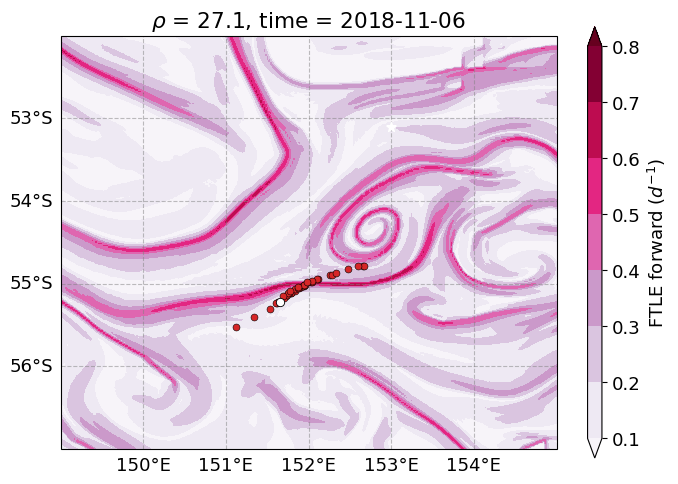

In [101]:
# Plot the initial frame
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())


im = ax.contourf(ftle_fw.lon, ftle_fw.lat, ftle_fw.lambda1.isel(time = 0).T,
                levels=np.arange(0.1,0.9,0.1), cmap='PuRd', extend='both')

# particle release location
ax.scatter(pfile.lon[i, 0].values, pfile.lat[i, 0].values, marker = '*', color = 'w', s = 50, zorder = 100, transform=ccrs.PlateCarree()) 
p_sel = ax.plot(lon[d_ind, b_sel], lat[d_ind, b_sel], "o", c="w", markersize = 6, markeredgecolor='k', markeredgewidth = 0.6, transform=ccrs.PlateCarree(), zorder = 100)
p = ax.plot(lon[b], lat[b], "o", c="tab:red", markersize = 5, markeredgecolor='k', markeredgewidth = 0.4, transform=ccrs.PlateCarree(), zorder = 80)


gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title(r"$\rho$" + f" = {d}, " + "time = " + str(ds.coords['time'].values[0].astype('M8[D]')))
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.tick_params(axis='x', pad=50)

fig.colorbar(im, ax=ax, label = r'FTLE forward ($d^{-1}$)', shrink = 0.7, aspect = 30)

# Next create a function that updates the values for the colormesh, contours, trajectory and title.
def animate(frame):
    
    ax.clear()
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    im = ax.contourf(ftle_fw.lon, ftle_fw.lat, ftle_fw.lambda1.isel(time = frame).T, 
              levels=np.arange(0.1,0.9,0.1), cmap='PuRd', extend='both')
    
    #initial particle position
    ax.scatter(pfile.lon[i, 0].values, pfile.lat[i, 0].values, marker = '*', color = 'w', s = 50, zorder = 100, transform=ccrs.PlateCarree()) 
    
    # update particle positions
    b_sel = time[d_ind] == plottimes[frame]
    p_sel = ax.plot(lon[d_ind, b_sel], lat[d_ind, b_sel], "o", c="w", markersize = 6, markeredgecolor='k', markeredgewidth = 0.6, transform=ccrs.PlateCarree(), zorder = 100)
    b = time == plottimes[frame]
    ax.plot(lon[b], lat[b], "o", c="tab:red", markersize = 5,markeredgecolor='k', markeredgewidth = 0.4, transform=ccrs.PlateCarree(), zorder = 80)
    
    gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    
    ax.set_title(r"$\rho$" + f" = {d}, " + "time = " + str(ds.coords['time'].values[frame].astype('M8[D]')))
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.tick_params(axis='x', pad=50)
    

# use the FuncAnimation function to create the animation
ani = FuncAnimation(
    fig,             
    animate,
    # fargs=p, 
    frames=len(ds.time),      
    interval=220, # ms between frames
)

plt.show()

In [102]:
# to view the animation in the notebook
HTML(ani.to_jshtml())

In [10]:
# # to save the animation
# ani.save(f'animations/fw_FTLE_{d}_with_col{lt}.gif', dpi = 300)